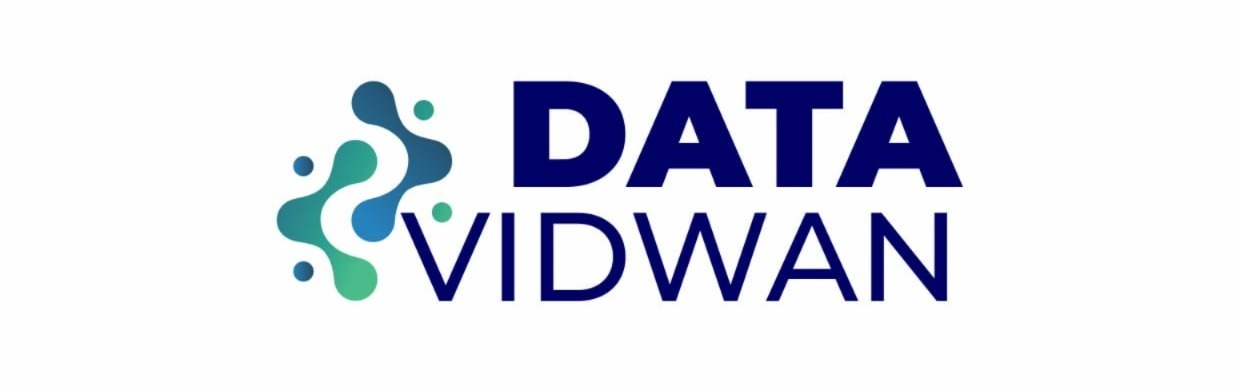

# **Support Vector Machine (SVM)**

SVM is a supervised machine learning algorithm mainly used for classification. Its goal is to separate different classes with the best possible boundary.

**Role of SVM**

The role of SVM is to create a separating boundary (hyperplane) that clearly divides the classes. It tries to keep the largest possible distance (margin) between the classes so the model can generalize well.

**How SVM Works**

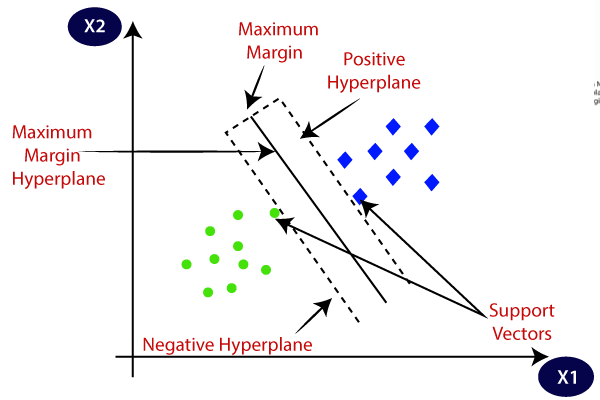

- SVM tries to draw a line or plane that separates the classes.
- It checks which data points lie closest to this boundary.
- These closest points are called support vectors.
- Using these support vectors, SVM positions the boundary such that the margin is maximized.

The final goal of SVM is that all points of the same class (same color) should lie on one side of the boundary, and all points of the other class should lie on the opposite side.


**Mathematically**

Maximize margin = 2 / ||w||

Where:
- w = weight vector of the hyperplane
- ||w|| = magnitude of w

Here, w is the vector that defines the hyperplane.

A larger margin means better separation.

Libraries like scikit-learn automatically calculate this.

**Important Terms**

- Hyperplane - The decision boundary.
- Margin - Distance between hyperplane and nearest points of each class.
- Support Vectors - Critical points that determine the hyperplane.
- Kernel - Function used when data is not linearly separable.



**Why We Use SVM**

SVM is used when the goal is to separate classes clearly and accurately. It focuses on finding the best possible boundary between classes by maximizing the margin. Because of this margin-based approach, SVM often performs better than many algorithms when the data is small or medium in size and the class separation is important.

**How SVM is Different from Other algorithms**

- SVM does not just create any boundary; it creates the boundary with maximum margin.
- SVM depends only on support vectors, not the whole dataset, which makes it stable.
- It can handle non-linear data using kernels, while many algorithms struggle without transformations.
- It is less affected by outliers because only the closest points matter in building the model.

**Problems Where SVM Is Commonly Used**

- Binary classification (spam vs not spam, disease vs no disease).
- Image classification.
- Text classification.
- Face recognition.
- Situations where classes are separable or need clear margin separation.
- Small to medium datasets where high accuracy is needed.

**Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease.csv to heart_disease.csv


In [4]:
df = pd.read_csv('heart_disease.csv')
df.head()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.head()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.shape

(303, 14)

In [7]:
df.columns

Index(['age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   gender    303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Check Missing Value**

In [10]:
# Check missing values
df.isnull().sum()

,0
age,0
gender,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**EDA: Univariate Analysis**

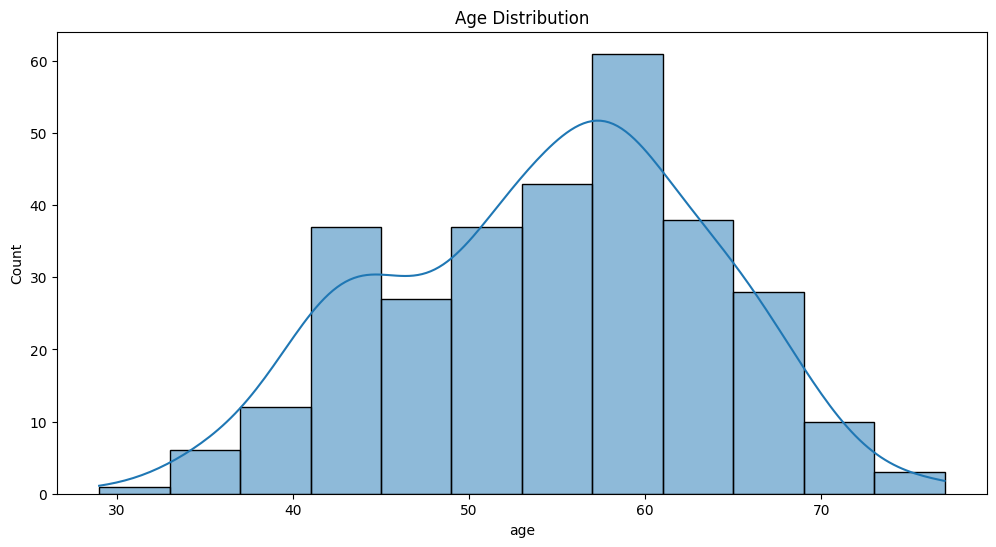

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

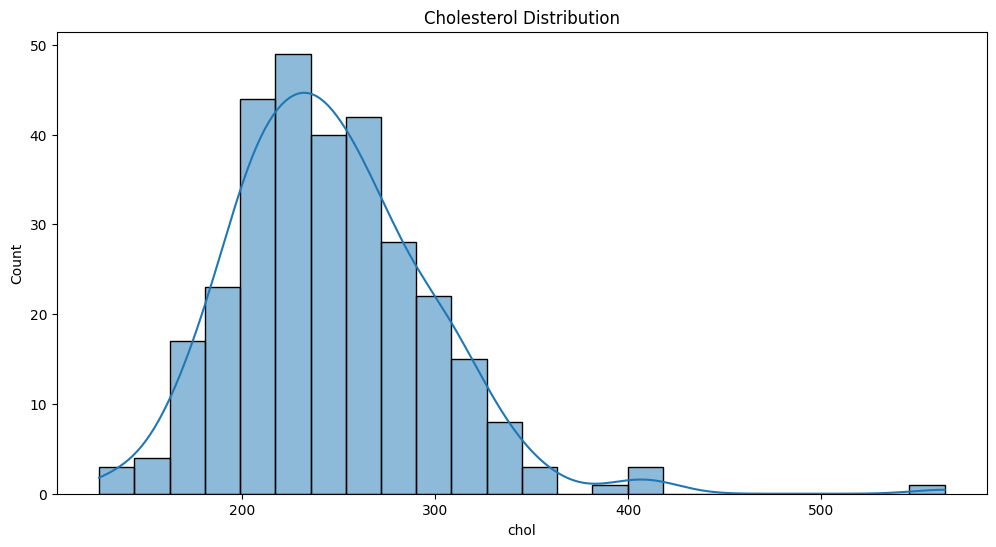

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df['chol'], kde=True)
plt.title('Cholesterol Distribution')
plt.show()

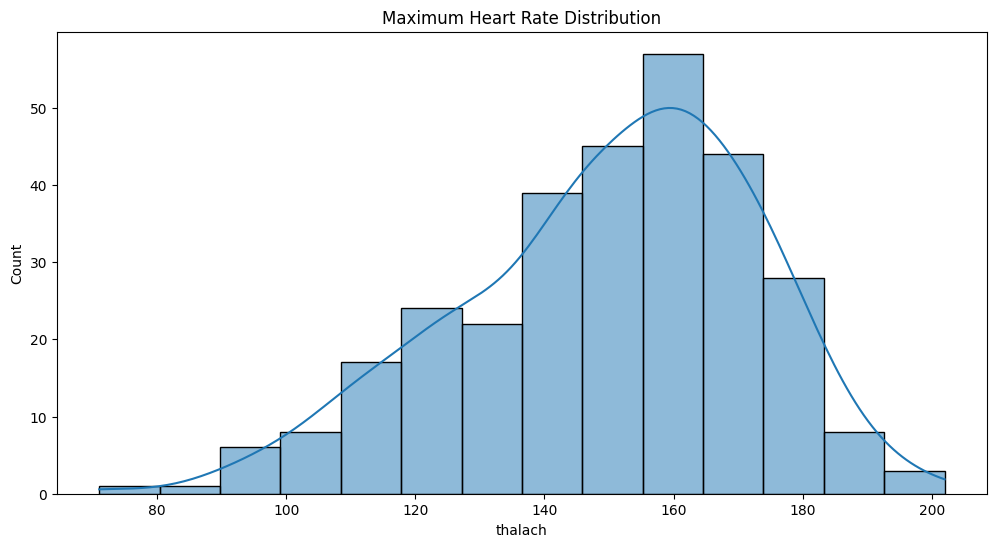

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(df['thalach'], kde=True)
plt.title('Maximum Heart Rate Distribution')
plt.show()

**Countplots for Categorical Columns**

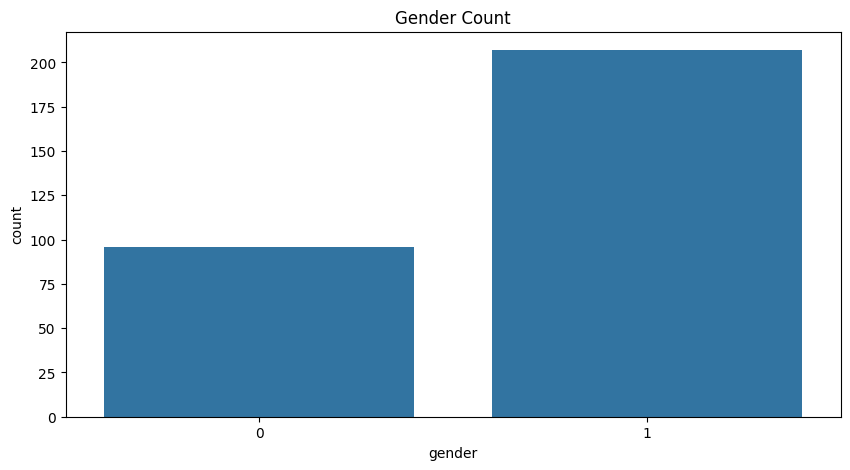

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='gender', data=df)
plt.title('Gender Count')
plt.show()

**Splitting Features and Target**

In [18]:
X = df.drop('target', axis=1)
y = df['target']

**Train-Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**SVM Model Training**

In [21]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

**Why We Use a Kernel in SVM**

1. Most datasets are not linearly separable.
- If you draw a straight line, the classes will still mix.
- This includes medical datasets like heart disease.

2. Kernel converts the data into a higher-dimensional space
- where it becomes easier to separate the classes with a clear boundary.

3. SVM only works well when the data becomes separable, and kernels help create that separability.

**Why RBF Kernel Specifically**

- It handles complex, curved boundaries.
- It performs very well on medium-sized datasets.
- It is the most stable and accurate kernel for noisy real-world data.
- It can draw circular, non-linear, or flexible boundaries that a straight line cannot.

**Model Evaluation**

In [22]:
y_pred = svm_model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8688524590163934

Confusion Matrix:
 [[26  3]
 [ 5 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



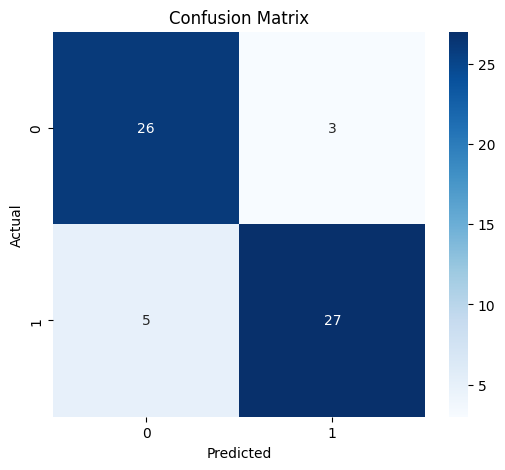

In [24]:
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Inference**

In [28]:
sample_input = pd.DataFrame({
    'age': [67],
    'gender': [1],
    'cp': [0],
    'trestbps': [160],
    'chol': [286],
    'fbs': [0],
    'restecg': [0],
    'thalach': [108],
    'exang': [1],
    'oldpeak': [1.5],
    'slope': [1],
    'ca': [3],
    'thal': [2]
})

sample_input
scaled_input = scaler.transform(sample_input)
prediction = svm_model.predict(scaled_input)[0]

print("prediction:", prediction)

prediction: 0


- 0 → No heart disease
- 1 → Heart disease

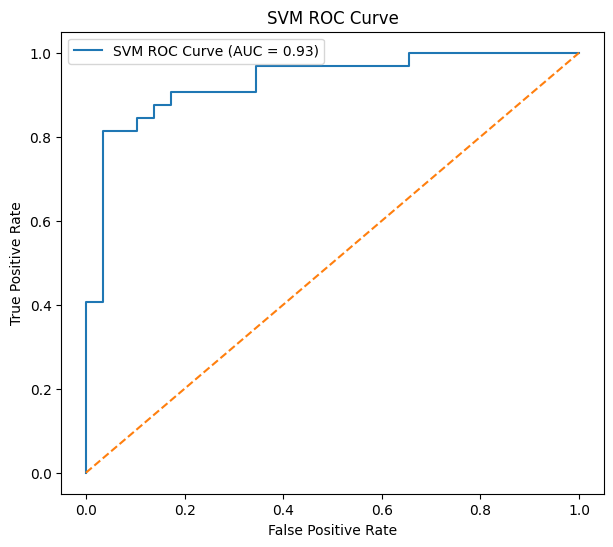

In [29]:
from sklearn.metrics import roc_curve, auc

# Get probability scores using decision_function
y_scores = svm_model.decision_function(X_test)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label='SVM ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

**Meaning of ROC Curve**

The ROC (Receiver Operating Characteristic) curve shows how well your SVM model can separate two classes:

• Class 0 → No Heart Disease
• Class 1 → Heart Disease

It does this by plotting two values at different thresholds:

1. True Positive Rate (TPR)
- How many actual heart-disease patients the model correctly detects.

2. False Positive Rate (FPR)
- How many healthy people are incorrectly predicted as having heart disease.



**How to Read This ROC Curve**

1. The blue curve represents your SVM model performance.
2. The orange diagonal line represents a bad model (random guessing).
3. Since the blue line is far above the orange line, the model is performing strongly.
4. AUC = 0.93, which means:
- 0.50 = random
- 0.70–0.80 = decent
- 0.80–0.90 = good
- 0.90+ = excellent

Your AUC is 0.93, so the model is excellent.

**In Simple Words**

- Your SVM model is very good at distinguishing between patients who have heart disease and those who do not.
- AUC of 0.93 means that in 93% of the cases, the model correctly ranks a heart-disease patient higher than a healthy patient.